In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import seaborn as sns

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_deriv(z):
    s = sigmoid(z)
    return s * (1 - s)

def fit(data, target, hidden_n=2, lr=0.1, epochs=5000):
    n_samples, n_features = data.shape

    history = defaultdict(list)

    W1 = np.random.randn(hidden_n,n_features)
    b1 = np.zeros((hidden_n,1))

    W2 = np.random.randn(1,hidden_n)
    b2 = np.zeros((1, 1))


    for epoch in range(epochs):

        target = target.reshape(1, -1)

        z1 = np.dot(W1,data.T) + b1
        a1 = sigmoid(z1)

        z2 = np.dot(W2,a1) + b2
        a2 = sigmoid(z2)

        loss = -np.sum(target*np.log10(a2) + (1-target)*np.log10(1-a2))
        # print("a2",a2.shape,"target",target.shape)
        # print("a1",a1.shape,"W1",W1.shape)
        # print("W2",W2.shape)

        dz2 = a2 - target
        dW2 = np.dot(dz2,a1.T)
        db2 = np.sum(dz2, axis=1, keepdims=True)


        dz1 = np.dot(dz2.T,W2).T * sigmoid_deriv(z1)
        dW1 = np.dot(dz1,data)
        db1 = np.sum(dz1, axis=1, keepdims=True)

        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

        history["W1"].append(W1.copy())
        history["W2"].append(W2.copy())
        history["b1"].append(b1.copy())
        history["b2"].append(b2.copy())
        history["loss"].append(loss.copy())

    return W1, b1, W2, b2, history


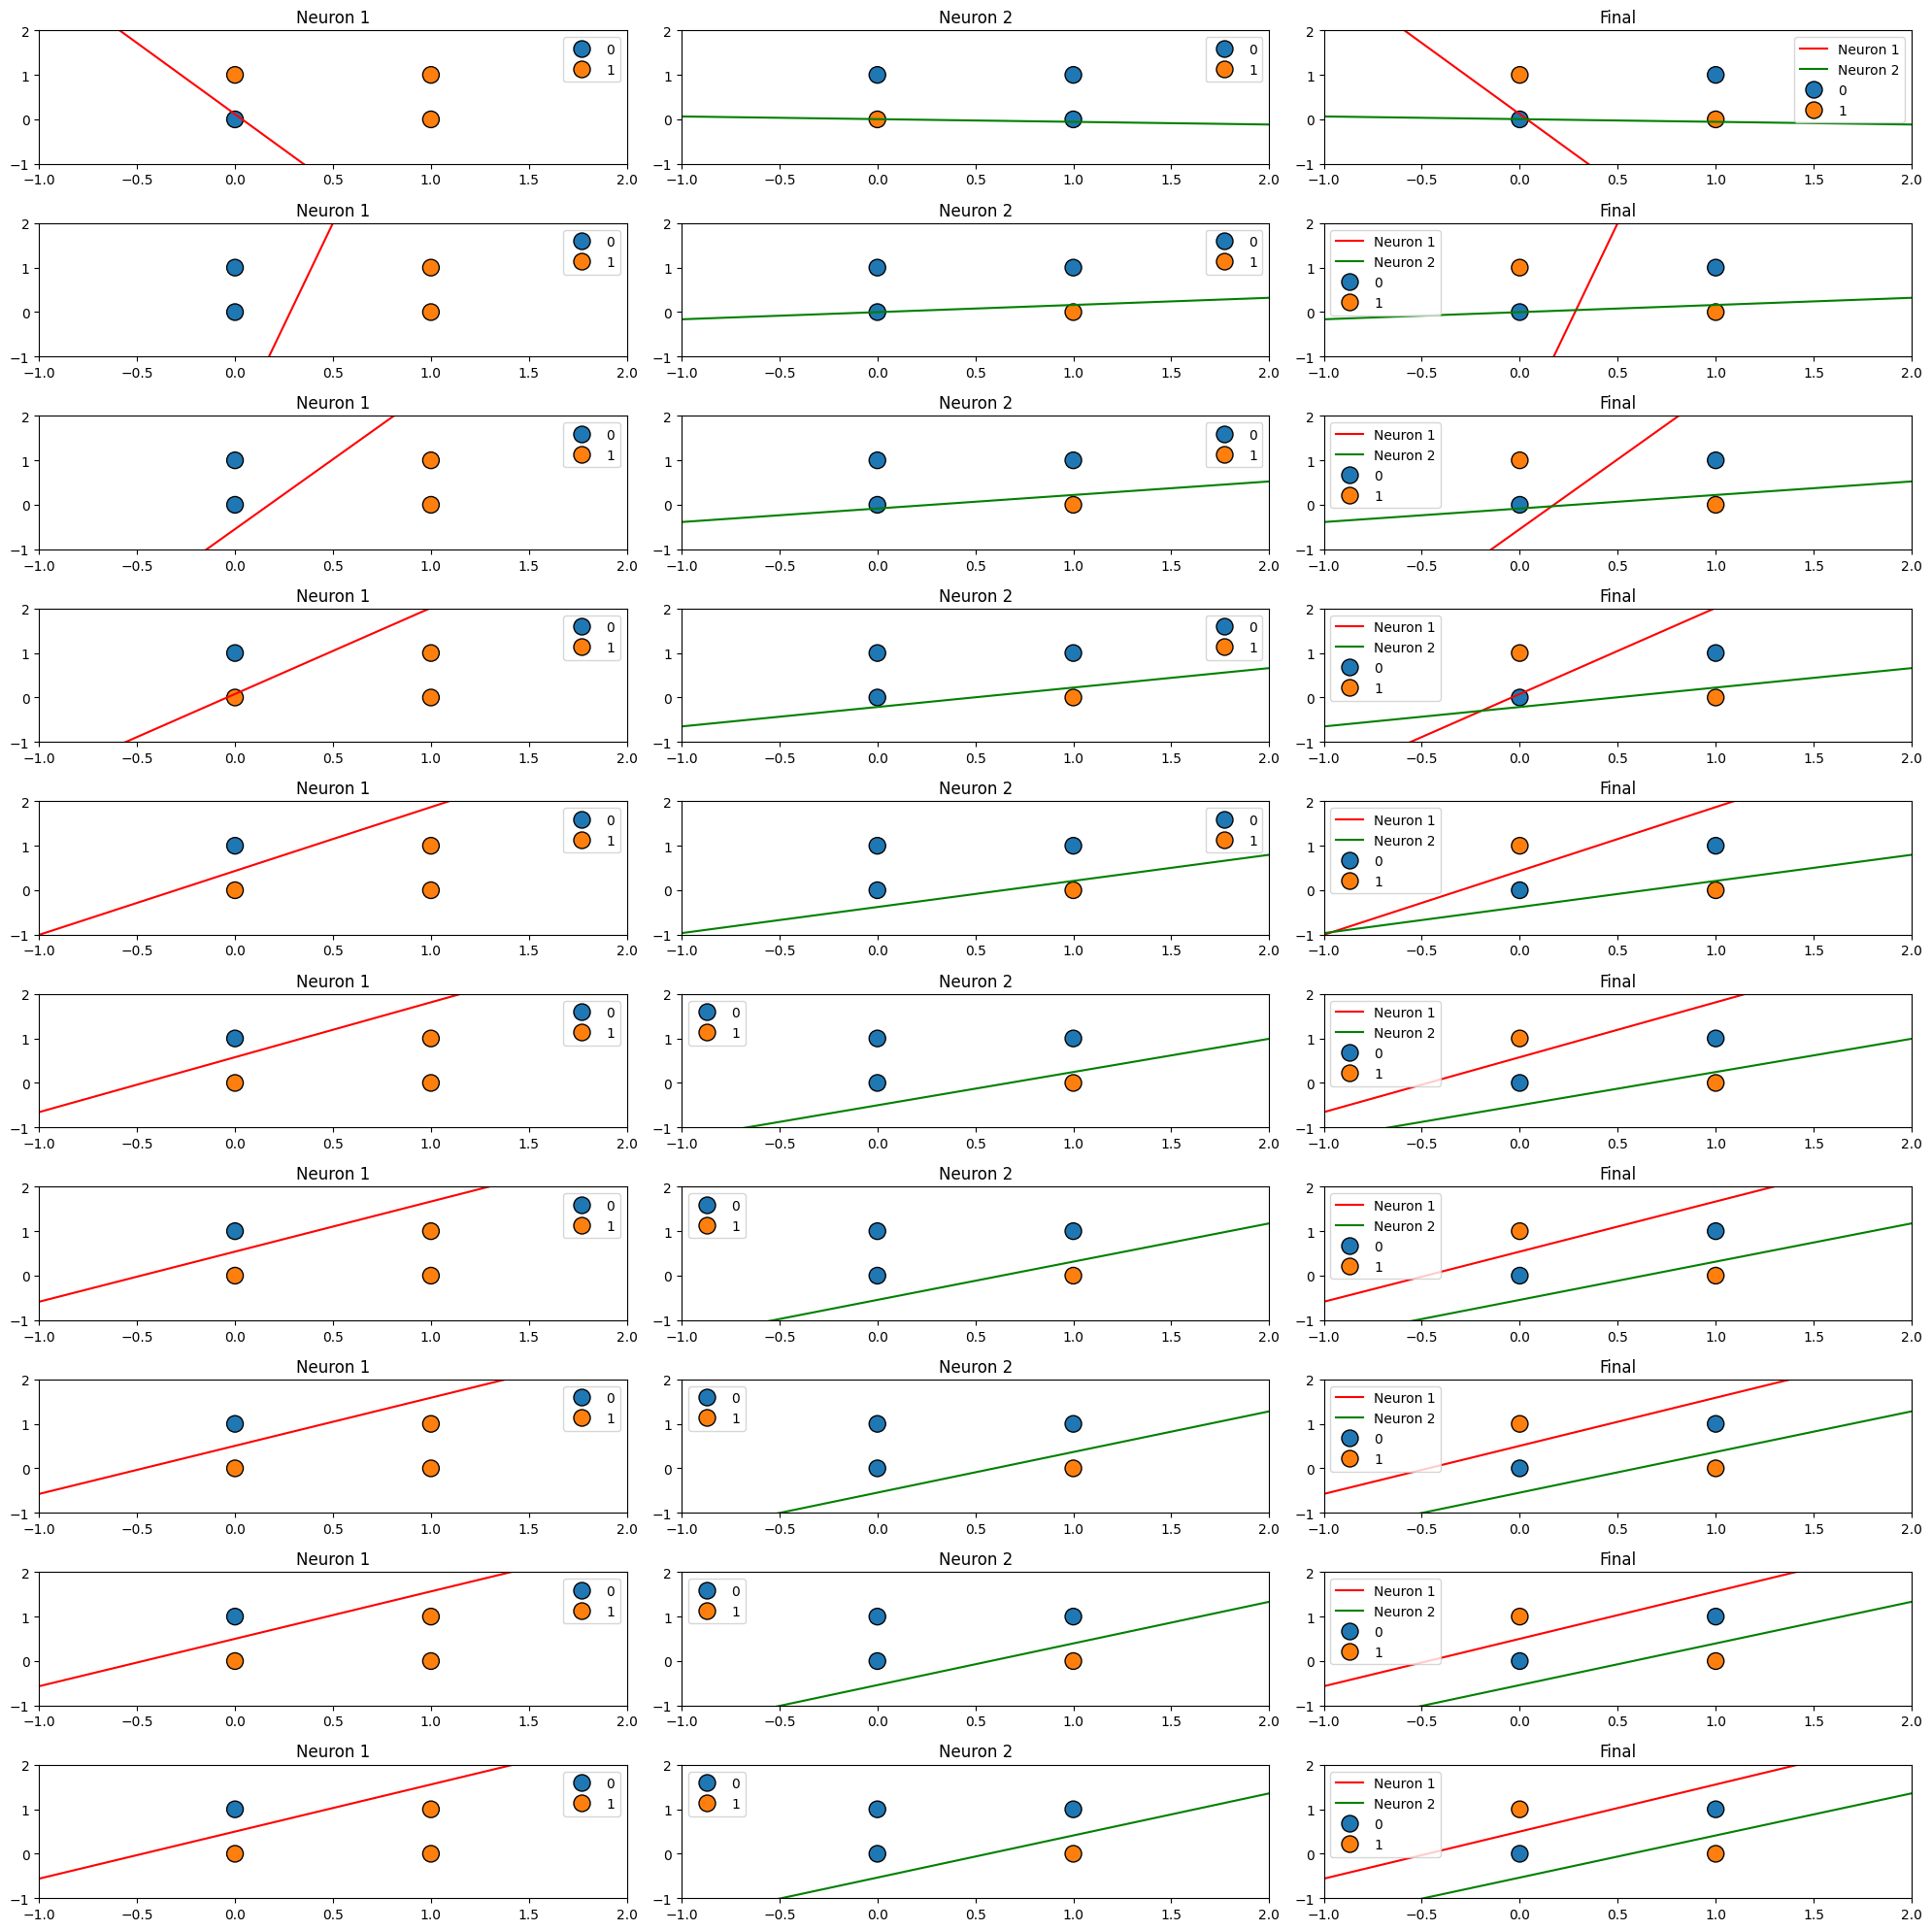

In [2]:
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,1,1,0])
epochs = 1000

W1,b1,W2,b2,history = fit(X,y,hidden_n=2,lr=0.1,epochs=epochs)
plt.figure(figsize=(20,20))
plot_id = 1
data = X
x1_vals = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100)

for i in range(0, epochs, 100):
    W1 = history["W1"][i]
    b1 = history["b1"][i]
    W2 = history["W2"][i]
    b2 = history["b2"][i]

    a1 = sigmoid(np.dot(W1,data.T) + b1)
    h1 = a1[0,:]
    h2 = a1[1,:]
    h1_w1, h1_w2 = W1[0,:]
    h2_w1, h2_w2 = W1[1,:]

    y_h1 = - (np.dot(x1_vals,h1_w1) + b1[0,:])/h1_w2
    y_h2 = - (np.dot(x1_vals,h2_w1) + b1[1,:])/h2_w2

    a2 = sigmoid(np.dot(W2,a1) + b2)
    Z = (a2 > 0.5).astype(int).reshape(y.shape)
    h1 = (h1 > 0.5).astype(int).reshape(y.shape)
    h2 = (h2 > 0.5).astype(int).reshape(y.shape)

    plt.subplot(10,3,plot_id)
    plt.title("Neuron 1")
    plt.plot(x1_vals, y_h1, color="red")
    sns.scatterplot(x=X[:,0], y=X[:,1], hue=h1, s=150, edgecolors='k')
    plt.xlim(-1,2)
    plt.ylim(-1,2)
    plot_id += 1

    plt.subplot(10,3,plot_id)
    plt.title("Neuron 2")
    plt.plot(x1_vals, y_h2, color="green")
    sns.scatterplot(x=X[:,0], y=X[:,1], hue=h2, s=150, edgecolors='k')
    plt.xlim(-1,2)
    plt.ylim(-1,2)
    plot_id += 1

    plt.subplot(10,3,plot_id)
    plt.title("Final")
    plt.plot(x1_vals, y_h1, color="red",label = "Neuron 1")
    plt.plot(x1_vals, y_h2, color="green",label = "Neuron 2")
    sns.scatterplot(x=X[:,0], y=X[:,1], hue=y, s=150, edgecolors='k')
    plt.xlim(-1,2)
    plt.ylim(-1,2)
    plot_id += 1

plt.tight_layout()
plt.show()